# 01: Data Exploration

Load and explore the synthetic patient dataset.

Goals:
- Understand data structure and quality
- Identify missing values, outliers, distributions
- Visualize key patient characteristics

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# Load data
df = pd.read_csv('../data/raw/nurseassist_patient_dataset.csv')
print(f"Dataset loaded: {df.shape[0]} patients, {df.shape[1]} features")

df.head()


In [14]:
# Check for missing values
print("Missing values by column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing_Count'] > 0])
print(f"\nTotal rows: {len(df)}")
print(f"Columns with no missing values: {(missing == 0).sum()} / {len(df.columns)}")

Missing values by column:
                      Missing_Count  Percentage
Medication_Allergies              9    4.285714
Food_Other_Allergies             19    9.047619

Total rows: 210
Columns with no missing values: 21 / 23


In [17]:
df[df.isnull().any(axis=1)]

,Patient_ID,Patient_Name,Age,Sex,Weight_kg,Primary_Illness,Symptoms,Temperature_C,Heart_Rate_bpm,Systolic_BP_mmHg,...,eGFR_mL_min,Blood_Glucose_mmol_L,Pain_0_10,Consciousness_Orientation,Medication_Allergies,Food_Other_Allergies,Medical_History,Treatment_Impact_Notes,Medication_Dosage_Fixed_Period,Medication_Reasoning
0,PT-1001,Emily Carter,19,Female,58,Common cold,"Runny nose, sore throat, mild cough, fatigue",37.2,82,112,...,105,5.1,2,Alert and oriented x3,NaN,Peanuts,No major medical history,Supportive care usually appropriate; avoid unn...,Acetaminophen 500 mg PO every 6 hours as neede...,"Common cold is usually viral, so supportive ca..."
3,PT-1004,Raj Patel,56,Male,90,Hypertension,"Headache, dizziness, blurred vision",36.9,88,178,...,82,6.0,4,Alert and oriented x3,ACE inhibitors,NaN,Type 2 diabetes and obesity,Very high BP needs medical review; diabetes af...,Amlodipine 5 mg PO once daily for 30 days if p...,Very high blood pressure with headache and blu...
10,PT-1011,Ava Wright,72,Female,60,Sepsis risk,"Confusion, fever, rapid breathing, chills",39.4,116,80,...,44,11.1,7,Intermittently confused,NSAIDs,NaN,Chronic kidney disease,Renal function may require dose adjustment; av...,Clinician-led broad-spectrum IV antibiotics pe...,"Hypotension, confusion, fever, tachycardia, an..."
14,PT-1015,Carlos Walker,66,Male,109,Gastrointestinal infection,"Abdominal cramps, diarrhea, nausea, poor oral ...",38.3,116,94,...,69,6.6,7,Intermittently confused,NSAIDs,NaN,Iron-deficiency anemia,Avoid nsaids if relevant.,Oral rehydration solution 200-250 mL after eac...,"Vomiting and diarrhea can cause dehydration, s..."
15,PT-1016,Luis Young,51,Male,64,Post-operative wound infection,"Increased pain, wound redness, mild confusion,...",39.4,115,129,...,71,6.7,7,Alert but fatigued,NaN,Sesame,Chronic kidney disease,Renal function may require dose adjustment.,Clindamycin 300 mg PO every 6-8 hours for 5-7 ...,Recent surgery with fever and wound changes ma...
35,PT-1036,Elena Smith,64,Female,81,Pneumonia,"Fatigue, fever, productive cough, shortness of...",39.3,105,130,...,31,9.1,6,Alert and oriented x3,Morphine,NaN,Diabetes,Monitor blood glucose and infection healing ri...,Doxycycline 100 mg PO/IV every 12 hours for 5-...,"Respiratory infection with fever, productive c..."
39,PT-1040,Lucas Baker,20,Male,65,Asthma exacerbation,"Cough, shortness of breath, chest tightness",36.4,112,112,...,72,8.2,5,Alert but anxious,NaN,Fish,No major medical history,Monitor oxygen saturation and respiratory effort.,Albuterol inhaler 2-4 puffs every 20 minutes f...,Wheezing and increased work of breathing sugge...
44,PT-1045,Dylan Martinez,51,Male,115,Influenza,"Chills, myalgia, headache",39.5,102,136,...,75,5.5,7,Intermittently confused,NaN,Latex,Immunocompromised,Standard supportive care and reassessment base...,Oseltamivir 75 mg PO twice daily for 5 days if...,Influenza may benefit from antiviral therapy w...
46,PT-1047,Layla Carter,53,Female,62,Strep throat,"Headache, fatigue, painful swallowing, fever, ...",38.8,100,135,...,84,6.5,7,Alert but anxious,NSAIDs,NaN,Recurrent tonsillitis,Avoid nsaids if relevant.,Amoxicillin 500 mg PO every 12 hours for 10 da...,Bacterial throat infection may require clinici...
94,PT-1095,Ruby Scott,29,Female,89,Urinary tract infection,"Fever, dysuria, urinary frequency, lower abdom...",38.9,88,146,...,110,10.8,5,Alert and oriented x3,NaN,Fish,No major medical history,Standard supportive care and reassessment base...,Nitrofurantoin 100 mg PO every 12 hours for 5 ...,Urinary symptoms with fever or recurrence may ...


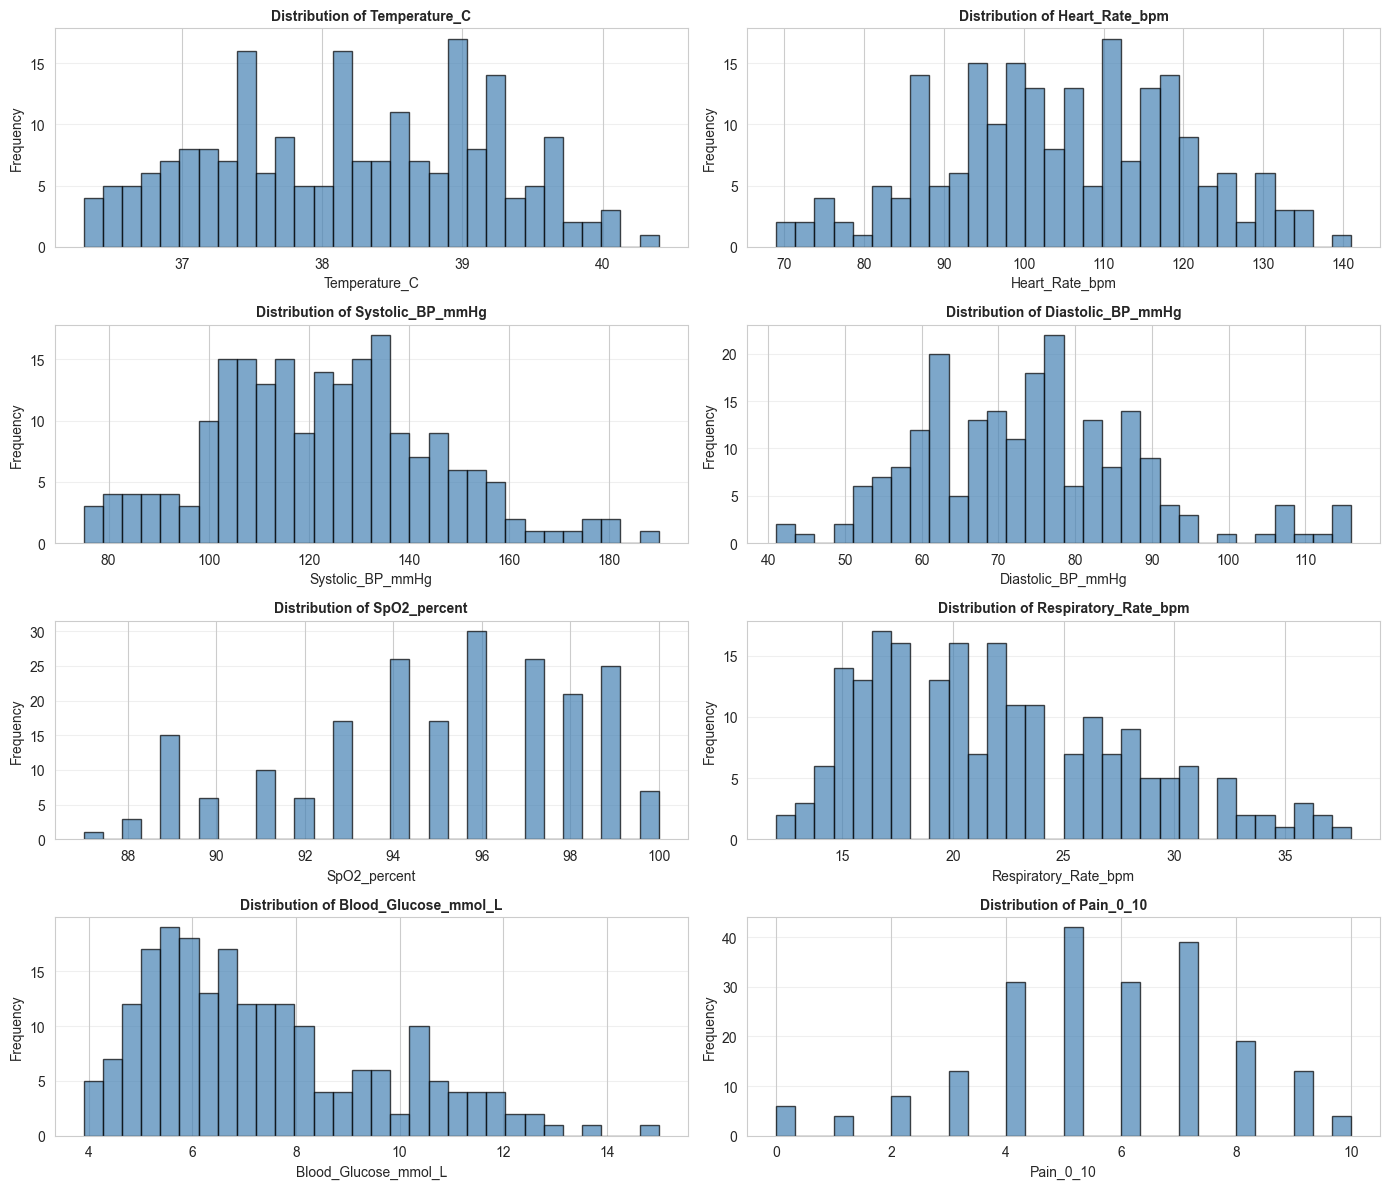

In [18]:
# Explore vital signs distributions
vital_signs = ['Temperature_C', 'Heart_Rate_bpm', 'Systolic_BP_mmHg', 
               'Diastolic_BP_mmHg', 'SpO2_percent', 'Respiratory_Rate_bpm', 
               'Blood_Glucose_mmol_L', 'Pain_0_10']

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, vital in enumerate(vital_signs):
    axes[idx].hist(df[vital], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {vital}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel(vital)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Explore categorical features
print("=== CATEGORICAL FEATURES ===\n")

print("Primary Illnesses (Top 15):")
print(df['Primary_Illness'].value_counts().head(15))
print(f"Total unique illnesses: {df['Primary_Illness'].nunique()}\n")

print("Sex distribution:")
print(df['Sex'].value_counts())
print(f"Percentage:\n{(df['Sex'].value_counts() / len(df) * 100).round(2)}\n")

print("Consciousness/Orientation:")
print(df['Consciousness_Orientation'].value_counts())
print()

print("Medication Allergies (Top 10):")
allergies = df['Medication_Allergies'].dropna().value_counts().head(10)
print(allergies)
print(f"Patients with medication allergies: {df['Medication_Allergies'].notna().sum()} / {len(df)}\n")

print("Food/Other Allergies (Top 10):")
food_allergies = df['Food_Other_Allergies'].dropna().value_counts().head(10)
print(food_allergies)
print(f"Patients with food allergies: {df['Food_Other_Allergies'].notna().sum()} / {len(df)}\n")

# Age distribution
print("Age distribution:")
print(f"Mean age: {df['Age'].mean():.1f} years")
print(f"Age range: {df['Age'].min()} - {df['Age'].max()} years")
print(f"Median age: {df['Age'].median():.0f} years")

# Weight distribution
print(f"\nWeight distribution:")
print(f"Mean weight: {df['Weight_kg'].mean():.1f} kg")
print(f"Weight range: {df['Weight_kg'].min()} - {df['Weight_kg'].max()} kg")

=== CATEGORICAL FEATURES ===

Primary Illnesses (Top 15):
Primary_Illness
Influenza                          27
Gastrointestinal infection         21
Common cold                        19
Pneumonia                          19
Post-operative wound infection     18
COPD exacerbation                  17
Urinary tract infection            16
Hypertension                       15
Sepsis risk                        15
Strep throat                       14
Skin/wound infection               14
Asthma exacerbation                14
Sepsis risk from skin infection     1
Name: count, dtype: int64
Total unique illnesses: 13

Sex distribution:
Sex
Female    105
Male      105
Name: count, dtype: int64
Percentage:
Sex
Female    50.0
Male      50.0
Name: count, dtype: float64

Consciousness/Orientation:
Consciousness_Orientation
Intermittently confused                      46
Alert but anxious                            45
Alert but fatigued                           39
Alert and oriented x3         

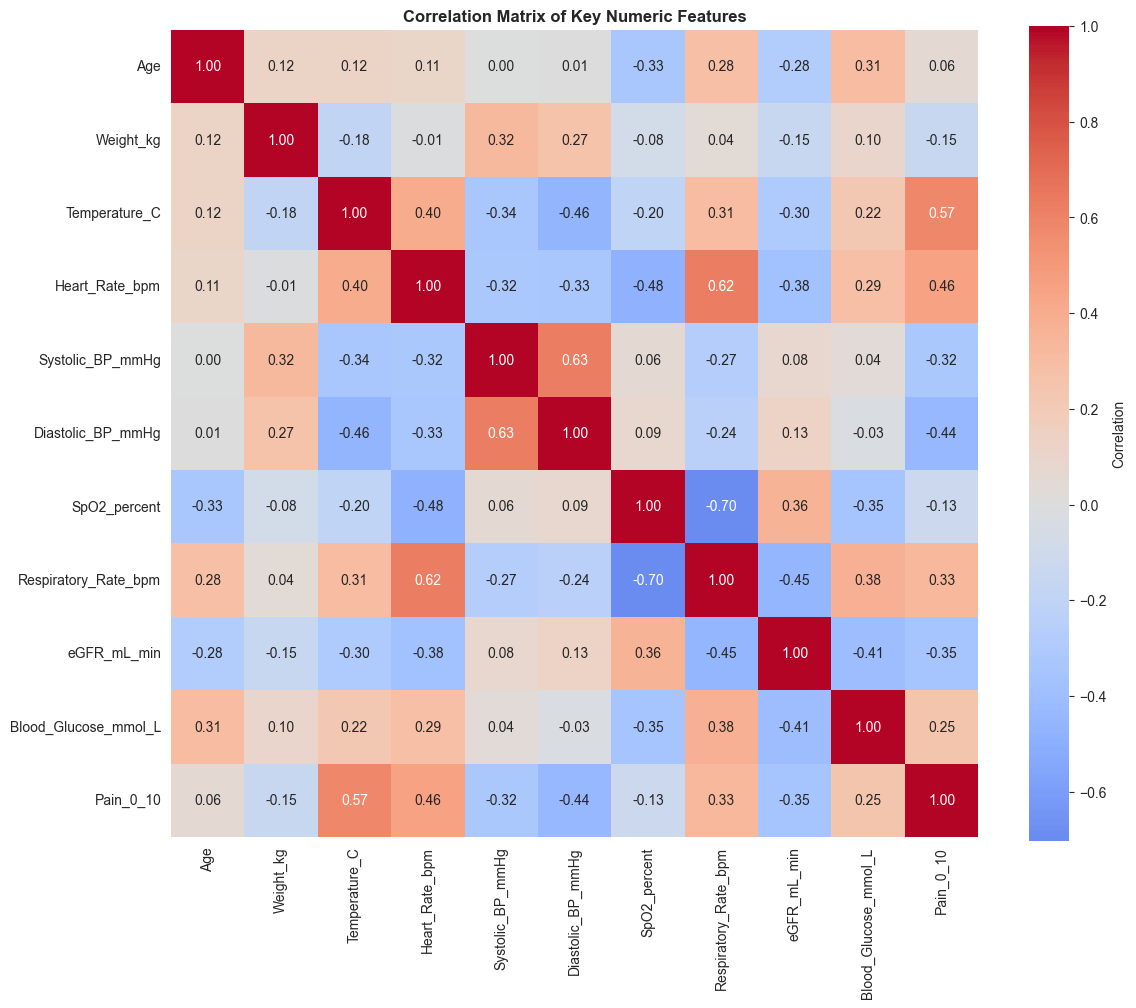

In [10]:
# Correlation analysis of vital signs
numeric_cols = ['Age', 'Weight_kg', 'Temperature_C', 'Heart_Rate_bpm', 
                'Systolic_BP_mmHg', 'Diastolic_BP_mmHg', 'SpO2_percent', 
                'Respiratory_Rate_bpm', 'eGFR_mL_min', 'Blood_Glucose_mmol_L', 'Pain_0_10']

correlation_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix of Key Numeric Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

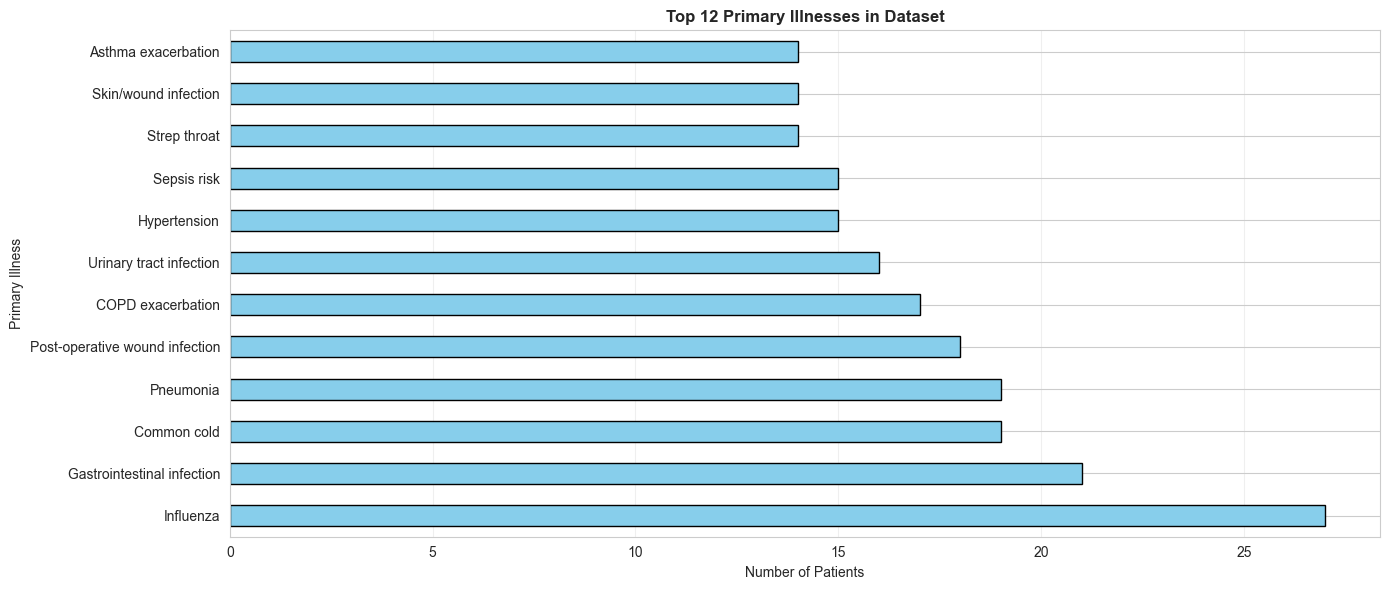

Total unique primary illnesses: 13


In [11]:
# Visualize primary illnesses
illness_counts = df['Primary_Illness'].value_counts().head(12)
fig, ax = plt.subplots(figsize=(14, 6))
illness_counts.plot(kind='barh', ax=ax, color='skyblue', edgecolor='black')
ax.set_title('Top 12 Primary Illnesses in Dataset', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Patients')
ax.set_ylabel('Primary Illness')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total unique primary illnesses: {df['Primary_Illness'].nunique()}")

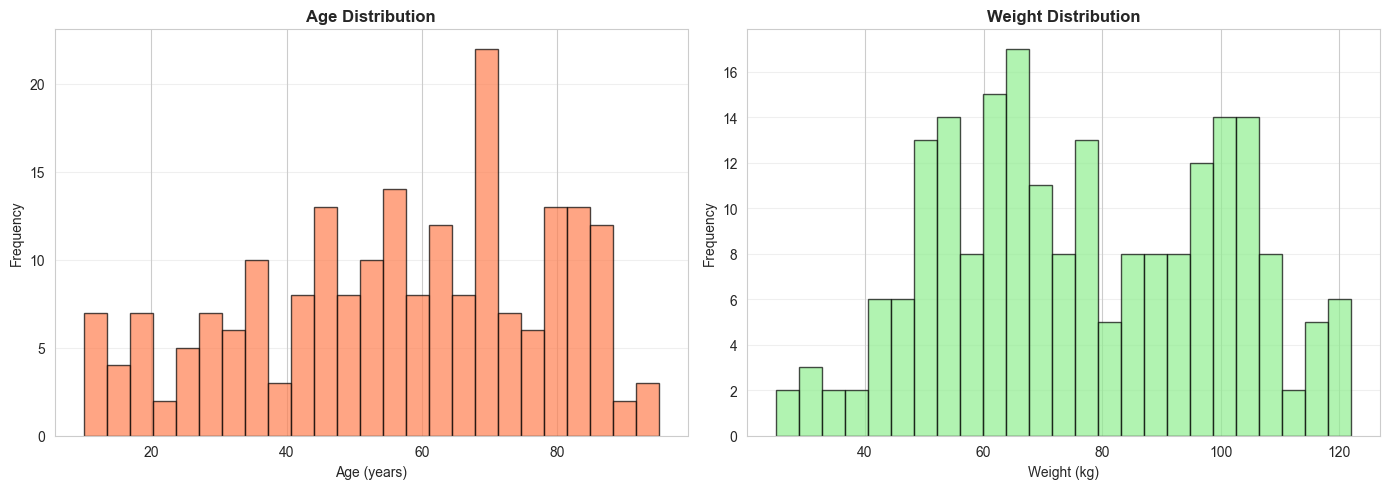

In [12]:
# Visualize age and weight distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Age'], bins=25, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(df['Weight_kg'], bins=25, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Weight Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Weight (kg)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()